# 1. Imports

In [171]:
import os
import pandas as pd
import numpy as np
from time import time
from glob import glob

# Matplotlib
from matplotlib import pyplot as plt

# Tensorflow
#os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess_input
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess_input

# Sklearn
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Seaborn
import seaborn as sns


# 2. Préparation des données

In [172]:
path = "/content/drive/MyDrive/data/Flipkart"
#path = "./data/Flipkart"

In [173]:
data = pd.read_csv(path+'/cleaned_data.csv')

In [174]:
data.head()

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,...,category,tokenized_description,stemmed_description,combined_postag_wnet,lemmatized_description,lemmatized_description_text,tokenized_product_name,combined_postag_wnet_product_name,lemmatized_product_name,lemmatized_product_name_text
0,55b85ea15a1536d46b7190ad6fff8ce7,2016-04-30 03:22:56 +0000,http://www.flipkart.com/elegance-polyester-mul...,Elegance Polyester Multicolor Abstract Eyelet ...,"[""Home Furnishing >> Curtains & Accessories >>...",CRNEG7BKMFFYHQ8Z,1899.0,899.0,55b85ea15a1536d46b7190ad6fff8ce7.jpg,False,...,Home Furnishing,"['key', 'features', 'elegance', 'polyester', '...","['key', 'featur', 'eleg', 'polyest', 'multicol...","[('key', 'n'), ('features', 'v'), ('elegance',...","['key', 'feature', 'elegance', 'polyester', 'm...",key feature elegance polyester multicolor abst...,"['elegance', 'polyester', 'multicolor', 'abstr...","[('elegance', 'n'), ('polyester', 'n'), ('mult...","['elegance', 'polyester', 'multicolor', 'abstr...",elegance polyester multicolor abstract eyelet ...
1,7b72c92c2f6c40268628ec5f14c6d590,2016-04-30 03:22:56 +0000,http://www.flipkart.com/sathiyas-cotton-bath-t...,Sathiyas Cotton Bath Towel,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEGFZHGBXPHZUH,600.0,449.0,7b72c92c2f6c40268628ec5f14c6d590.jpg,False,...,Baby Care,"['specifications', 'sathiyas', 'cotton', 'bath...","['specif', 'sathiya', 'cotton', 'bath', 'towel...","[('specifications', 'n'), ('sathiyas', 'n'), (...","['specification', 'sathiyas', 'cotton', 'bath'...",specification sathiyas cotton bath towel bath ...,"['sathiyas', 'cotton', 'bath', 'towel']","[('sathiyas', 'n'), ('cotton', 'n'), ('bath', ...","['sathiyas', 'cotton', 'bath', 'towel']",sathiyas cotton bath towel
2,64d5d4a258243731dc7bbb1eef49ad74,2016-04-30 03:22:56 +0000,http://www.flipkart.com/eurospa-cotton-terry-f...,Eurospa Cotton Terry Face Towel Set,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEG6SHXTDB2A2Y,NaN,NaN,64d5d4a258243731dc7bbb1eef49ad74.jpg,False,...,Baby Care,"['key', 'features', 'eurospa', 'cotton', 'terr...","['key', 'featur', 'eurospa', 'cotton', 'terri'...","[('key', 'n'), ('features', 'v'), ('eurospa', ...","['key', 'feature', 'eurospa', 'cotton', 'terry...",key feature eurospa cotton terry face towel se...,"['eurospa', 'cotton', 'terry', 'face', 'towel'...","[('eurospa', 'n'), ('cotton', 'n'), ('terry', ...","['eurospa', 'cotton', 'terry', 'face', 'towel'...",eurospa cotton terry face towel set
3,d4684dcdc759dd9cdf41504698d737d8,2016-06-20 08:49:52 +0000,http://www.flipkart.com/santosh-royal-fashion-...,SANTOSH ROYAL FASHION Cotton Printed King size...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJT9UQWHDUBH4,2699.0,1299.0,d4684dcdc759dd9cdf41504698d737d8.jpg,False,...,Home Furnishing,"['key', 'features', 'santosh', 'royal', 'fashi...","['key', 'featur', 'santosh', 'royal', 'fashion...","[('key', 'n'), ('features', 'v'), ('santosh', ...","['key', 'feature', 'santosh', 'royal', 'fashio...",key feature santosh royal fashion cotton print...,"['santosh', 'royal', 'fashion', 'cotton', 'pri...","[('santosh', 'n'), ('royal', 'a'), ('fashion',...","['santosh', 'royal', 'fashion', 'cotton', 'pri...",santosh royal fashion cotton print king sized ...
4,6325b6870c54cd47be6ebfbffa620ec7,2016-06-20 08:49:52 +0000,http://www.flipkart.com/jaipur-print-cotton-fl...,Jaipur Print Cotton Floral King sized Double B...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJTHNGWVGWWQU,2599.0,698.0,6325b6870c54cd47be6ebfbffa620ec7.jpg,False,...,Home Furnishing,"['key', 'features', 'jaipur', 'print', 'cotton...","['key', 'featur', 'jaipur', 'print', 'cotton',...","[('key', 'n'), ('features', 'v'), ('jaipur', '...","['key', 'feature', 'jaipur', 'print', 'cotton'...",key feature jaipur print cotton floral king si...,"['jaipur', 'print', 'cotton', 'floral', 'king'...","[('jaipur', 'n'), ('print', 'n'), ('

In [175]:
data[['product_category_tree', 'category', 'uniq_id']].head(10)

,product_category_tree,category,uniq_id
0,"[""Home Furnishing >> Curtains & Accessories >>...",Home Furnishing,55b85ea15a1536d46b7190ad6fff8ce7
1,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",Baby Care,7b72c92c2f6c40268628ec5f14c6d590
2,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",Baby Care,64d5d4a258243731dc7bbb1eef49ad74
3,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",Home Furnishing,d4684dcdc759dd9cdf41504698d737d8
4,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",Home Furnishing,6325b6870c54cd47be6ebfbffa620ec7
5,"[""Watches >> Wrist Watches >> Maserati Time Wr...",Watches,893aa5ed55f7cff2eccea7758d7a86bd
6,"[""Watches >> Wrist Watches >> Camerii Wrist Wa...",Watches,f355cc1ccb08bd0d283ed979b7ee7515
7,"[""Watches >> Wrist Watches >> T STAR Wrist Wat...",Watches,dd0e3470a7e6ed76fd69c2da27721041
8,"[""Watches >> Wrist Watches >> Alfajr Wrist Wat...",Watches,41384da51732c0b4df3de8f395714fbb
9,"[""Watches >> Wrist Watches >> TAG Heuer Wrist ...",Watches,710ed5f2393a4b9e8823aa0029f71f93


In [176]:
data[['product_category_tree', 'category', 'uniq_id']].tail(10)

,product_category_tree,category,uniq_id
1040,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,3b465b02720ef7c930cb2e065a8fc05d
1041,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,b1644f47c7dfa58f8c06677f2a27ee09
1042,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,057836ecde71565f8ebdd576e41fdc96
1043,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,38782cce965307ddcdbedfcb7fa409c3
1044,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,be0f39341d771aac57084970f1ed6425
1045,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,958f54f4c46b53c8a0a9b8167d9140bc
1046,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,fd6cbcc22efb6b761bd564c28928483c
1047,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,5912e037d12774bb73a2048f35a00009
1048,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,c3edc504d1b4f0ba6224fa53a43a7ad6
1049,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,f2f027ad6a6df617c9f125173da71e44


In [177]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   uniq_id                            1050 non-null   object 
 1   crawl_timestamp                    1050 non-null   object 
 2   product_url                        1050 non-null   object 
 3   product_name                       1050 non-null   object 
 4   product_category_tree              1050 non-null   object 
 5   pid                                1050 non-null   object 
 6   retail_price                       1049 non-null   float64
 7   discounted_price                   1049 non-null   float64
 8   image                              1050 non-null   object 
 9   is_FK_Advantage_product            1050 non-null   bool   
 10  description                        1050 non-null   object 
 11  product_rating                     1050 non-null   objec

In [178]:
data.describe()

,retail_price,discounted_price
count,1049.000000,1049.000000
mean,2186.197331,1584.527169
std,7639.229411,7475.099680
min,35.000000,35.000000
25%,555.000000,340.000000
50%,999.000000,600.000000
75%,1999.000000,1199.000000
max,201000.000000,201000.000000


In [179]:
# Fonction pour convertir un DataFrame en tf.data.Dataset

preprocessor_map = {
    'resnet50': resnet_preprocess_input,
    'vgg16': vgg_preprocess_input
}
def preprocess(img_path, label, model='resnet50'):
    # Charger l'image depuis le chemin
    img = tf.io.read_file(img_path)
    # Décoder l'image en tenseur
    img = tf.image.decode_jpeg(img, channels=3)
    # Redimensionner l'image
    img = tf.image.resize(img, [224, 224])
    # Appliquer le prétraitement

    return img, label


def df_to_dataset(dataframe, batch_size=32, shuffle=True):
    paths = dataframe["imagepath"].values
    labels = dataframe["category"].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe))
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

In [180]:
le = LabelEncoder()
data["imagepath"] = data["image"].apply(lambda x: os.path.join(path, 'Images', x))
data['encoded_category'] = le.fit_transform(data['category'])

# Split train/val/test
train_df, temp_df = train_test_split(data, test_size=0.3, stratify=data["category"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.2, stratify=temp_df["category"], random_state=42)

# Transformation du dataframe en tf.data.datset
data_ds = df_to_dataset(data)

In [181]:
'''
images = glob(path+"/Images"+"*/*.jpg")
ids = [os.path.splitext(os.path.basename(fname))[0] for fname in images]

labels = []
for idx in ids:
    label = data.loc[data.uniq_id == idx, 'category'].values[0]
    labels.append(label)


data_ds = tf.keras.preprocessing.image_dataset_from_directory(
    path+"/Images",
    labels=labels,
    image_size=(224,224),
    seed=123,
    batch_size=32,
    shuffle=True,
    verbose=True
)

label_encoder = LabelEncoder()
true_labels = label_encoder.fit_transform(labels)
true_classes = labels
'''

'\nimages = glob(path+"/Images"+"*/*.jpg")\nids = [os.path.splitext(os.path.basename(fname))[0] for fname in images]\n\nlabels = []\nfor idx in ids:\n    label = data.loc[data.uniq_id == idx, \'category\'].values[0]\n    labels.append(label)\n\n\ndata_ds = tf.keras.preprocessing.image_dataset_from_directory(\n    path+"/Images",\n    labels=labels,\n    image_size=(224,224),\n    seed=123,\n    batch_size=32,\n    shuffle=True,\n    verbose=True\n)\n\nlabel_encoder = LabelEncoder()\ntrue_labels = label_encoder.fit_transform(labels)\ntrue_classes = labels\n'

CPU times: user 7.8 s, sys: 878 ms, total: 8.68 s
Wall time: 3.95 s


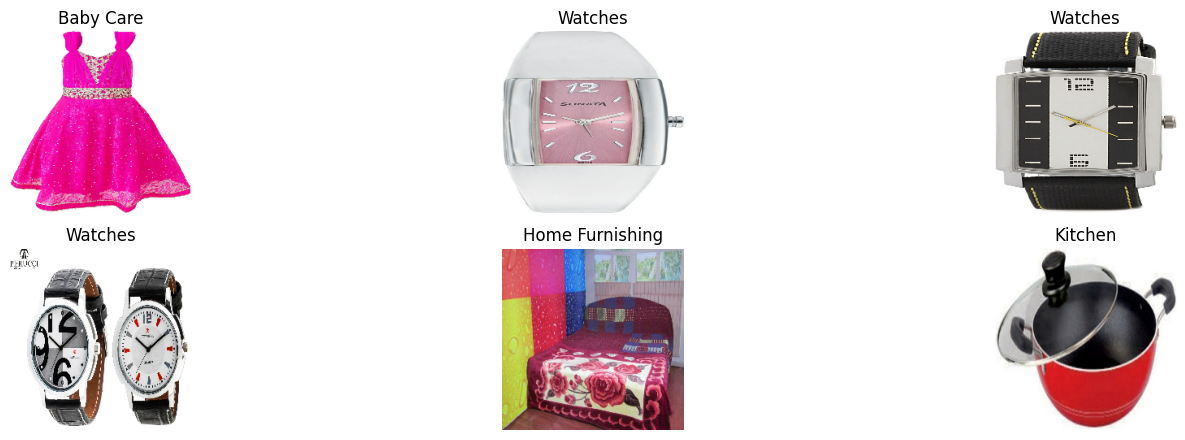

In [182]:
%%time
plt.figure(figsize=(18, 8))
for images, l in data_ds.take(4):
  for i in range(6):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(l[i].numpy().decode('utf-8'))
    plt.axis("off")

# 3. Extraction de caractéristiques via CNN (Transfer Learning)

In [183]:
def extract_features(dataset, model):
    features_list = []
    labels_list = []

    for images, labels in dataset:
        features = model.predict(images)
        features_list.append(features)
        labels_list.append(labels.numpy())

    # Concaténer tous les batches
    features_array = np.concatenate(features_list, axis=0)
    labels_array = np.concatenate(labels_list, axis=0)

    return features_array, labels_array

In [190]:
resnet50_data_ds = data_ds.map(lambda x,y: (resnet_preprocess_input(x), y))

## 3.1. Extraction des features avec ResNet50

In [185]:
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))

In [186]:
%%time
resnet50_features = base_model.predict(resnet50_data_ds)

33/33 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step
CPU times: user 3min 48s, sys: 15.8 s, total: 4min 3s
Wall time: 38.9 s


In [146]:
print("Data features shape:", features.shape)

Data features shape: (1050, 2048)


### 3.1.1. Réduction de dimensions

#### | PCA

In [187]:
%%time
s = StandardScaler()
pca = PCA(n_components=0.99)
resnet50_X_pca = pca.fit_transform(resnet50_features)

CPU times: user 4.02 s, sys: 22.9 ms, total: 4.05 s
Wall time: 539 ms


In [83]:
resnet50_X_pca

array([[ -0.4674216 ,   1.1152854 ,  -6.0725646 , ...,   1.6149367 ,
          1.3011116 ,  -0.9067184 ],
       [ 13.821494  , -12.778619  ,   0.9320741 , ...,   1.0456299 ,
          0.37853864,   0.4723296 ],
       [-11.955297  ,  -8.032337  ,   2.9813123 , ...,   0.49447605,
         -0.1740686 ,   0.5521981 ],
       ...,
       [ -5.3245854 ,   9.343819  ,  -3.9922204 , ...,  -1.1583619 ,
          0.378497  ,  -0.81197006],
       [-13.121452  ,  -9.729004  ,   2.0991223 , ...,  -0.24775864,
         -2.9036357 ,   1.0787287 ],
       [ -6.4358525 ,  -0.55662227,  -3.4461179 , ...,   0.5589083 ,
         -0.41900867,  -0.1747173 ]], dtype=float32)

#### | TSNE

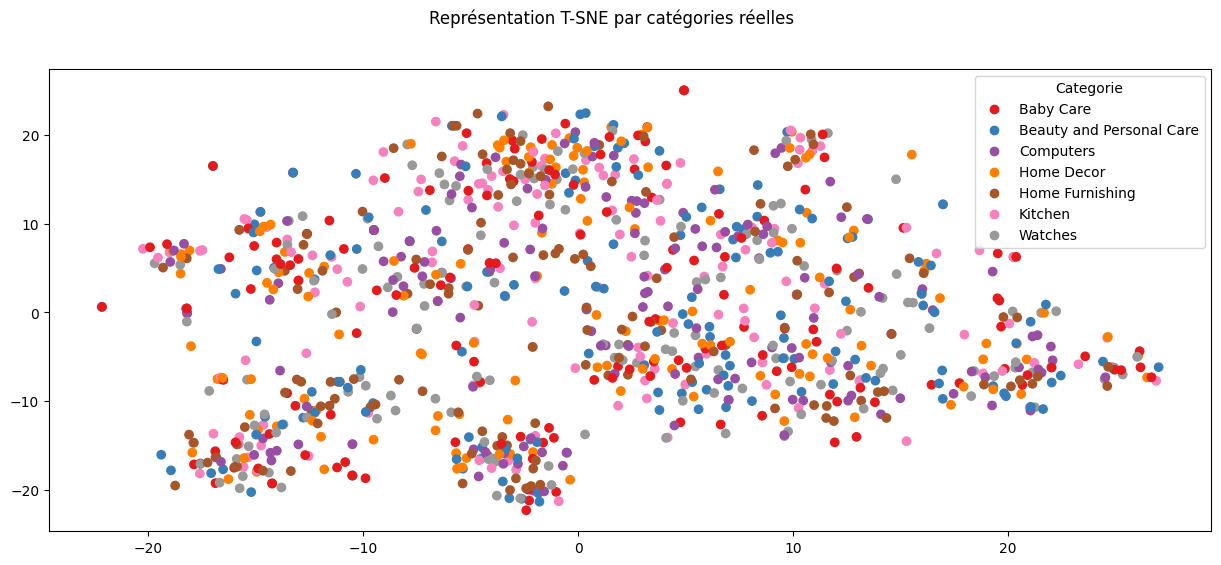

CPU times: user 14.9 s, sys: 22.1 ms, total: 14.9 s
Wall time: 3.67 s


In [188]:
%%time
fig = plt.figure(figsize=(15,6))
tsne_data = []
tsne = TSNE(n_components=2, perplexity=70, random_state=42)
resnet50_X_tsne = tsne.fit_transform(resnet50_X_pca)
scatter = plt.scatter(resnet50_X_tsne[:,0],resnet50_X_tsne[:,1], c=data.encoded_category, cmap='Set1')
plt.legend(handles=scatter.legend_elements()[0], labels=np.unique(data.category).tolist(), loc="best", title="Categorie")

plt.suptitle("Représentation T-SNE par catégories réelles")
plt.show()

### 3.1.2. Kmeans clustering

In [116]:
def tsne_visu_fct(X_tsne, y_cat_num, labels, ARI):
    fig = plt.figure(figsize=(15,6))
    ax = fig.add_subplot(121)

    scatter = ax.scatter(X_tsne[:,0],X_tsne[:,1], c=y_cat_num, cmap='Set1')
    ax.legend(handles=scatter.legend_elements()[0], labels=set(y_cat_num), loc="best", title="Categorie")
    plt.title(f"Représentation des produits par catégories réelles")

    ax = fig.add_subplot(122)
    scatter = ax.scatter(X_tsne[:,0],X_tsne[:,1], c=labels, cmap='Set1')
    ax.legend(handles=scatter.legend_elements()[0], labels=set(labels), loc="best", title="Clusters")
    plt.title(f"Représentation des produits par clusters => ARI={ARI}")
    plt.show()

ARI :  -0.0001


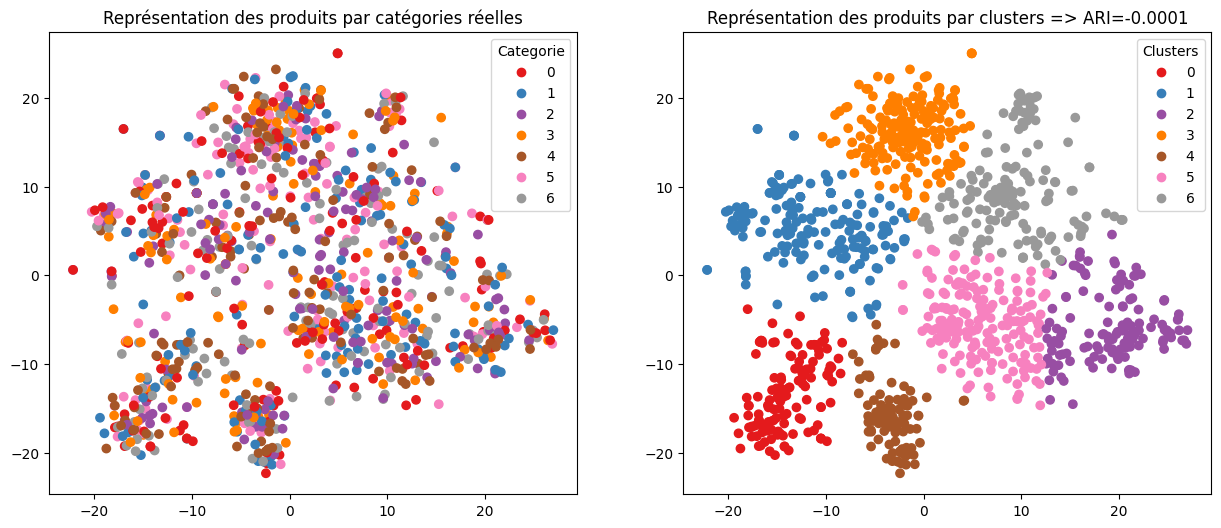

CPU times: user 1.37 s, sys: 29.9 ms, total: 1.4 s
Wall time: 563 ms


In [189]:
%%time

# Détermination des clusters à partir des données reduites
k=7

cls = KMeans(n_clusters=k, n_init=100, random_state=42)
clusters = cls.fit_predict(resnet50_X_tsne)
ARI = np.round(adjusted_rand_score(data.encoded_category, clusters),4)

print("ARI : ", ARI)
tsne_visu_fct(resnet50_X_tsne, data.encoded_category, clusters, ARI)

In [154]:
clustered_df = pd.DataFrame(data.category, columns=['category'])
clustered_df['cluster'] = clusters

In [155]:
clustered_df

,category,cluster
0,Home Furnishing,4
1,Baby Care,2
2,Baby Care,0
3,Home Furnishing,4
4,Home Furnishing,5
...,...,...
1045,Baby Care,0
1046,Baby Care,4
1047,Baby Care,1
1048,Baby Care,3


In [156]:
clustered_df.groupby("cluster")["category"].value_counts().to_frame().reset_index()

,cluster,category,count
0,0,Baby Care,29
1,0,Home Furnishing,27
2,0,Computers,22
3,0,Watches,20
4,0,Kitchen,17
5,0,Beauty and Personal Care,11
6,0,Home Decor,11
7,1,Baby Care,33
8,1,Watches,27
9,1,Beauty and Personal Care,23


In [158]:
from sklearn import metrics
conf_mat = metrics.confusion_matrix(data.encoded_category, clustered_df.cluster)
print(conf_mat)

[[29 33 21 14 23 17 13]
 [11 23 16 28 32 22 18]
 [22 22 15 19 29 21 22]
 [11 18 23 27 30 20 21]
 [27 22 22 19 24 22 14]
 [17 21 21 20 34 11 26]
 [20 27 18 27 25 21 12]]


In [160]:
print(metrics.classification_report(data.encoded_category, clustered_df.cluster))

              precision    recall  f1-score   support

           0       0.21      0.19      0.20       150
           1       0.14      0.15      0.15       150
           2       0.11      0.10      0.10       150
           3       0.18      0.18      0.18       150
           4       0.12      0.16      0.14       150
           5       0.08      0.07      0.08       150
           6       0.10      0.08      0.09       150

    accuracy                           0.13      1050
   macro avg       0.13      0.13      0.13      1050
weighted avg       0.13      0.13      0.13      1050



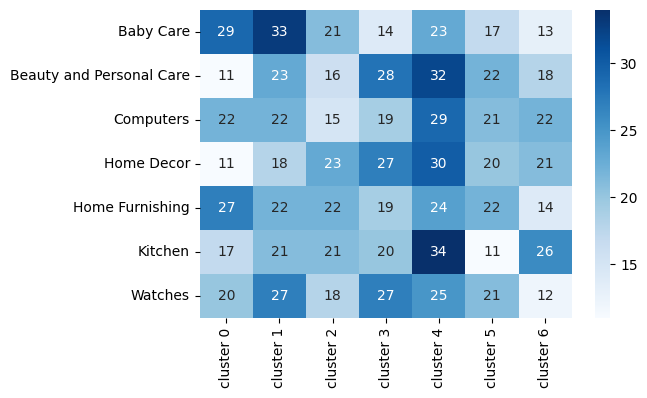

In [165]:
df_cm = pd.DataFrame(conf_mat, index = np.unique(data.category),
                  columns = [f"cluster {i}" for i in np.unique(data.encoded_category)])
plt.figure(figsize = (6,4))
sns.heatmap(df_cm, annot=True, cmap="Blues")
plt.show()

## 3.2 EXtraction des features avec VGG16

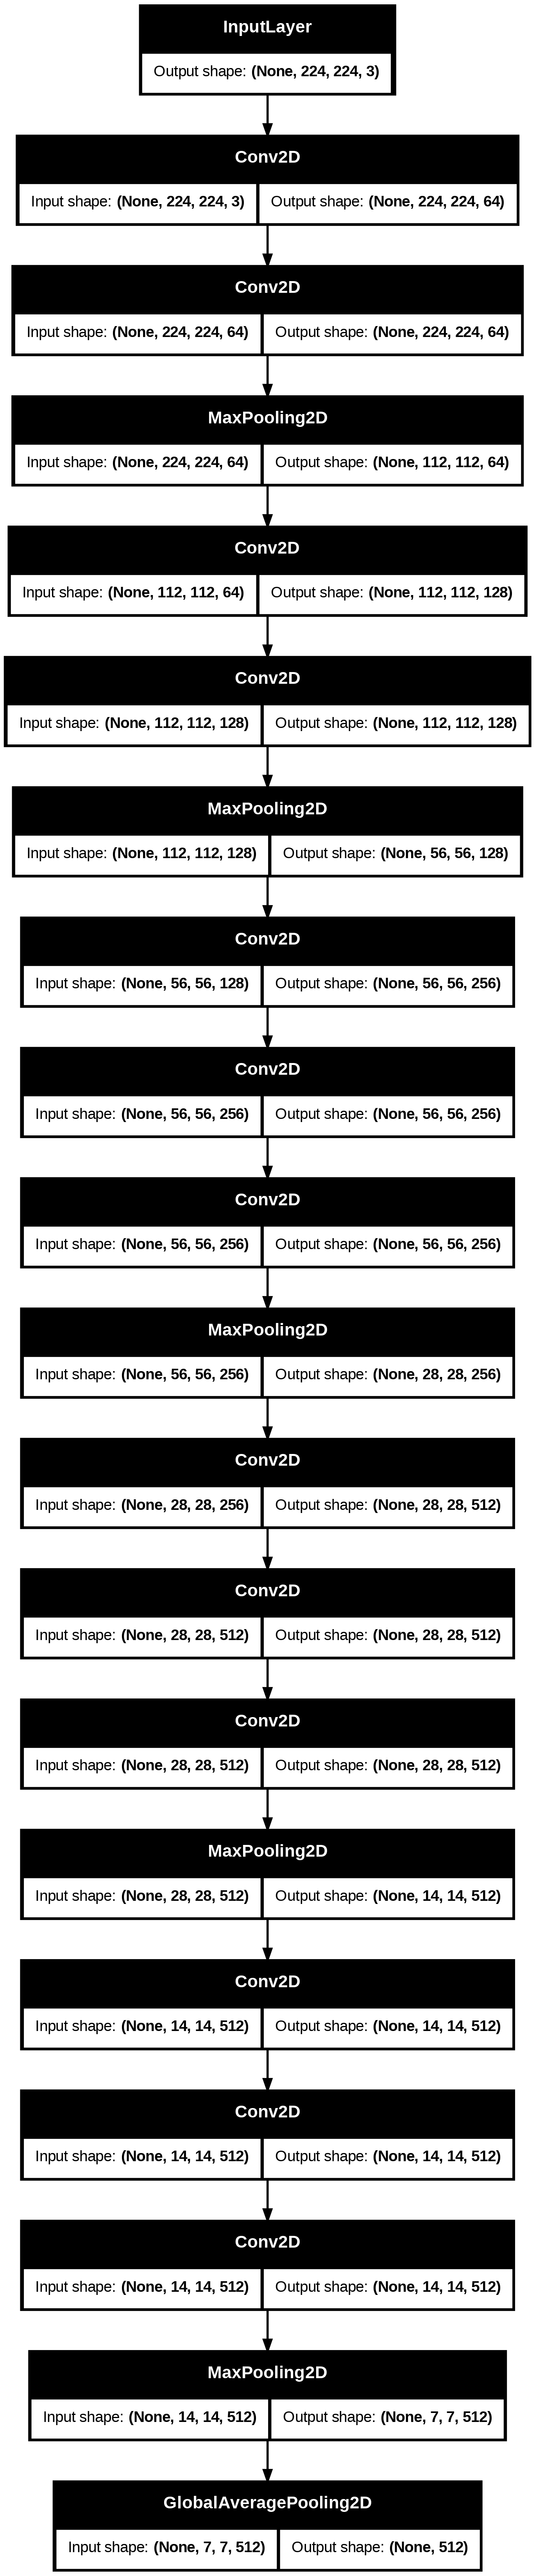

In [167]:
vgg_model = VGG16(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
tf.keras.utils.plot_model(vgg_model, show_shapes=True)

In [191]:
%%time
vgg_data_ds = data_ds.map(lambda x,y: (vgg_preprocess_input(x), y))
vgg_features = vgg_model.predict(vgg_data_ds)

Cause: could not parse the source code of <function <lambda> at 0x7c30a851c0e0>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7c30a851c0e0>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
33/33 ━━━━━━━━━━━━━━━━━━━━ 102s 3s/step
CPU times: user 12min 6s, sys: 26.8 s, total: 12min 33s
Wall time: 1min 42s


In [73]:
vgg_features.shape

(1050, 512)

### 3.2.1. Réduction de dimensions

#### | PCA

In [192]:
%%time
pca = PCA(n_components=0.9)
vgg_x_pca = pca.fit_transform(vgg_features)

CPU times: user 603 ms, sys: 1 ms, total: 604 ms
Wall time: 82 ms


#### | T-SNE

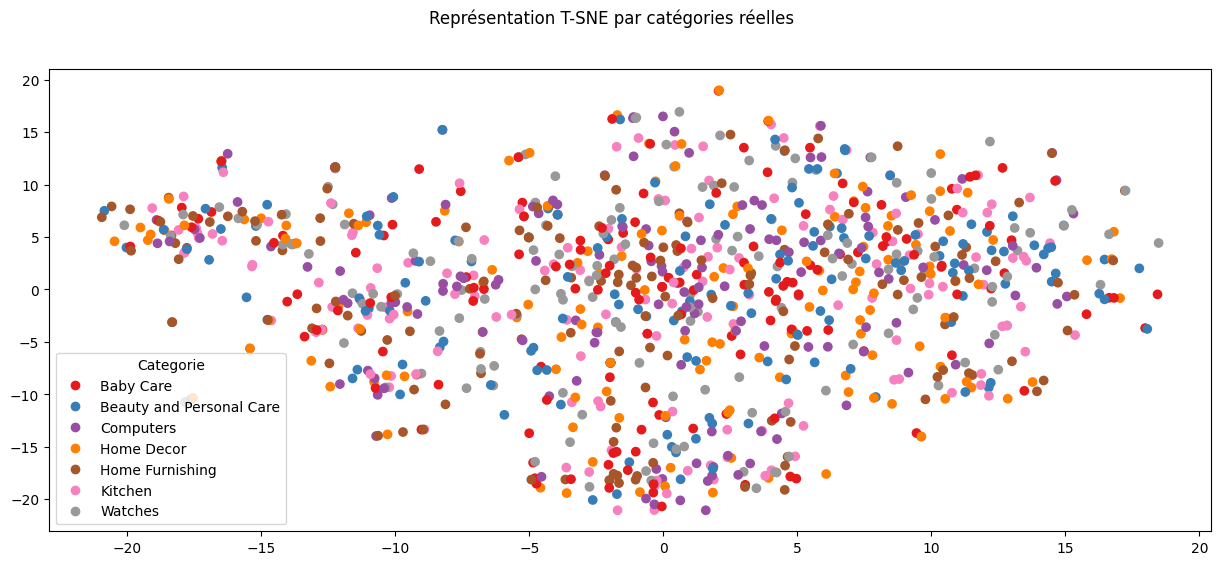

CPU times: user 16.2 s, sys: 14.5 ms, total: 16.2 s
Wall time: 3.95 s


In [197]:
%%time
fig = plt.figure(figsize=(15,6))
colors, _= pd.factorize(data.category)
tsne_data = []
tsne = TSNE(n_components=2, perplexity=70, random_state=42)
s = StandardScaler()
vgg_X_tsne = tsne.fit_transform(s.fit_transform(vgg_features))
scatter = plt.scatter(vgg_X_tsne[:,0],vgg_X_tsne[:,1], c=data.encoded_category.tolist(), cmap='Set1')
plt.legend(handles=scatter.legend_elements()[0], labels=np.unique(data.category).tolist(), loc="best", title="Categorie")

plt.suptitle("Représentation T-SNE par catégories réelles")
plt.show()

### 3.2.2 Kmeans clustering

ARI :  -0.0009


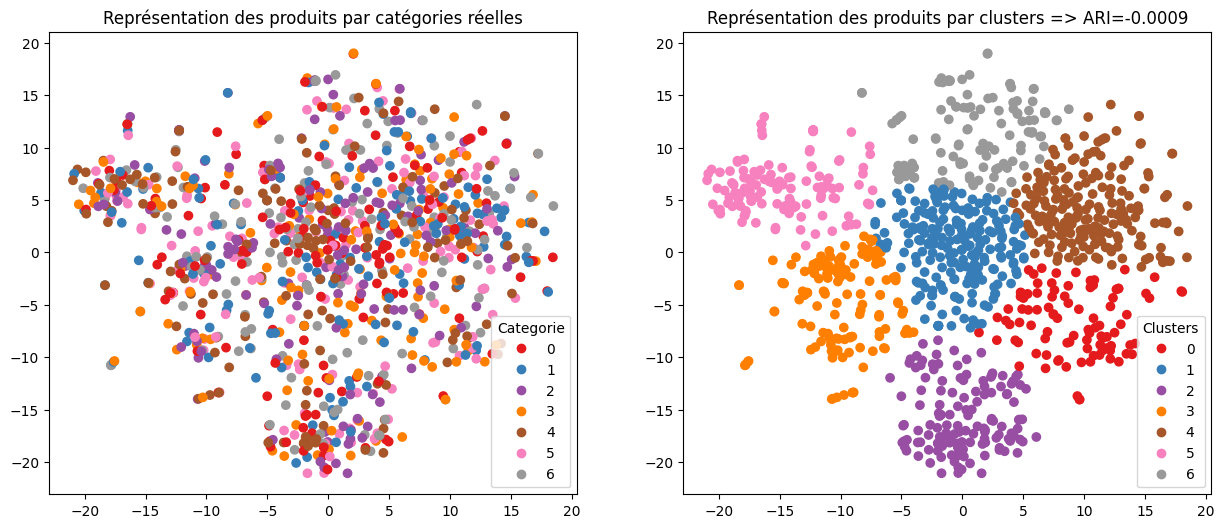

CPU times: user 1.42 s, sys: 53.3 ms, total: 1.47 s
Wall time: 645 ms


In [200]:
%%time

# Détermination des clusters à partir des données reduites
k=7
# Scaler
from sklearn.preprocessing import StandardScaler
s = StandardScaler()
s_vgg_X_tsne = vgg_X_tsne
cls = KMeans(n_clusters=k, n_init=100, random_state=42)
clusters = cls.fit_predict(s_vgg_X_tsne)
ARI = np.round(adjusted_rand_score(data.encoded_category, clusters),4)

print("ARI : ", ARI)
tsne_visu_fct(s_vgg_X_tsne, data.encoded_category.tolist(), clusters, ARI)

# 4. Classification supervisée

In [63]:
labels = []
for idx in ids:
    label = data.loc[data.uniq_id == idx, 'category'].values[0]
    labels.append(label)
le = LabelEncoder()
encoded_labels = le.fit_transform(labels)
train_ds, validation_ds = tf.keras.preprocessing.image_dataset_from_directory(
    path+"/Images",
    labels=encoded_labels.tolist(),
    image_size=(224,224),
    seed=123,
    batch_size=32,
    validation_split=0.3,
    subset='both',
    shuffle=True,
    verbose=True
)

Found 1050 files belonging to 7 classes.
Using 735 files for training.
Using 315 files for validation.


## 4.1 Augmentation du jeu d'entrainement

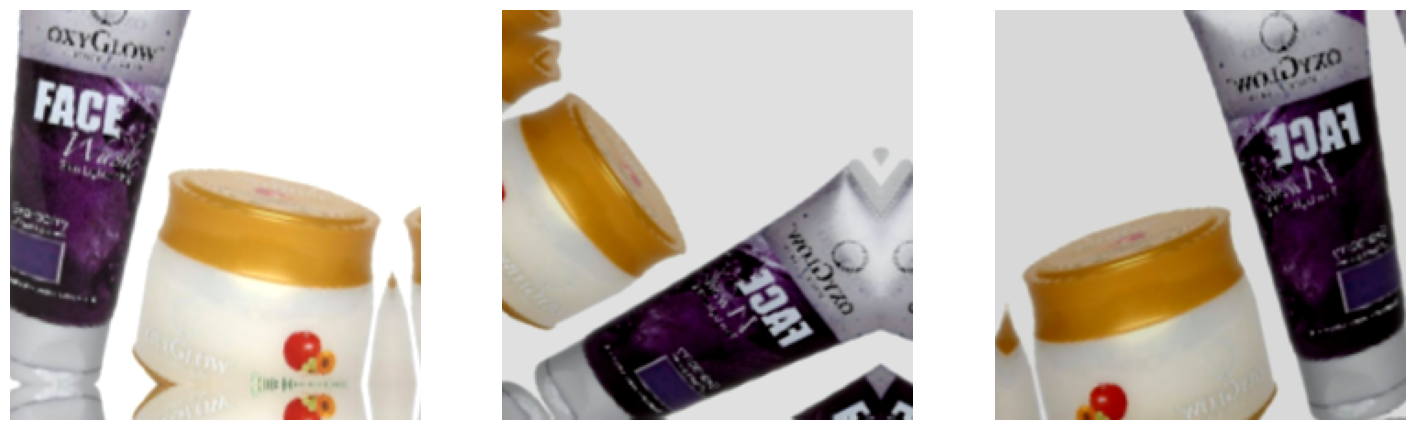

In [64]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),                       # Flip horizontal
    tf.keras.layers.RandomRotation(0.2),                            # Rotation aléatoire
    tf.keras.layers.RandomZoom(height_factor=0.2, width_factor=0.2),  # Zoom aléatoire
    tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),  # Translation aléatoire
    tf.keras.layers.RandomContrast(0.2),                            # Contraste aléatoire
    tf.keras.layers.RandomBrightness(factor=0.2),                   # Luminosité aléatoire (TF >= 2.15)
])

for image, labels in train_ds.take(1):
  plt.figure(figsize=(18, 8))
  first_image = image[0]
  for i in range(3):
    ax = plt.subplot(1, 3, i + 1)
    augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
    plt.imshow(augmented_image[0] / 255)
    #plt.title(labels[i].numpy().decode('utf-8'))
    plt.axis('off')

In [65]:
# Data augmentation appliquée à chaque image du dataset
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

# Batch + préchargement
#train_ds = train_ds.batch(32, drop_remainder=True).prefetch(tf.data.AUTOTUNE)


In [66]:
val_batches = tf.data.experimental.cardinality(validation_ds)

#On prend 20% du validation_dataset
test_ds = validation_ds.take(val_batches // 4)

#On prend les 80%  restant
validation_ds = validation_ds.skip(val_batches // 4)

print('Number of validation batches: %d' % tf.data.experimental.cardinality(validation_ds))
print('Number of test batches: %d' % tf.data.experimental.cardinality(test_ds))

Number of validation batches: 8
Number of test batches: 2


In [67]:
train_ds = train_ds.map(preprocess)
val_ds = validation_ds.map(preprocess)
test_ds = test_ds.map(preprocess)

## 4.2. Modélisation

In [68]:
# Chargement du modèle ResNet50 sans la tête (top) et avec poids ImageNet
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
# Gel des couches convolutives pour ne pas les réentraîner au début
base_model.trainable = False

In [69]:
%%time
train_features, train_labels = extract_features(train_ds, base_model)
val_features, val_labels = extract_features(val_ds, base_model)
test_features, test_labels = extract_features(test_ds, base_model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 993ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 985ms/step


KeyboardInterrupt: 

In [70]:
print("Train features shape:", train_features.shape)
print("Validation features shape:", val_features.shape)
print("Test features shape:", test_features.shape)

NameError: name 'train_features' is not defined

In [ ]:
from tensorflow.keras import Model, Input
from tensorflow.keras import layers

# Nouvelle tête
inputs = Input(shape=(224, 224, 3))
x = data_augmentation(inputs)  # Si tu veux l'inclure aussi dans le modèle
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(7, activation='softmax')(x)

model = Model(inputs, outputs)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

In [ ]:
import matplotlib.pyplot as plt

# Courbes Loss/Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.show()

In [ ]:
pycaret